In [ ]:
import os
import sys
sys.path.insert(0, '/'.join(os.getcwd().split('/')[:-2]))

from optical_volume import torch_geometry as Tgeometry
from optical_volume import propagator
from optical_volume import visualization
from optical_volume import utils

from py_wave_propagator import volume_prop as propagator

import numpy as np
from matplotlib import pyplot as plt

import torch
import torchvision.transforms.functional as F

import time

## Examplifying the Torch_Geometry module

#### 1. Cubes, spheres, ellipsoids and planes generation

In [3]:
# Grid and propagation parameters setup
wl = 640e-9
dx = dy = dz = torch.tensor(200e-9)
nx = ny = nz = 200

n_bg = torch.tensor(1.46)

spatial_resolution = [dx, dy, dz] # x=0->, y=0->, z=0->
grid_shape = [nx, ny, nz]

Coordiante system with size: 
 
              X = [0, 40.00 um], Res_X = 0.20 um
              Y = [0, 40.00 um], Res_Y = 0.20 um
              Z = [0, 40.00 um], Res_Z = 0.20 um
              Immersion RI: 1.4600000381469727
      


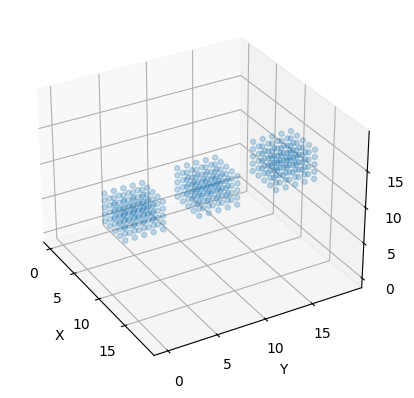

In [6]:
# Create the Geometry object with a shared grid
geometry = Tgeometry.Geometry(grid_shape, spatial_resolution, n_bg)

for i in range(1, 4):
    geometry.add_cube(center=(i*torch.tensor(10e-6), i*torch.tensor(10e-6), i*torch.tensor(10e-6)), side_length=torch.tensor(10e-6), RI=1.6, softness=1e-9)

grid = geometry.get_grid()
visualization.visualize_grid(grid.numpy(), n_bg.numpy(), factor=10, angle=(30, -30, 0))
# visualization.visualize_grid_vol(grid.numpy(), n_background=n_bg.numpy(), factor=2)

Coordiante system with size: 
 
              X = [0, 40.00 um], Res_X = 0.20 um
              Y = [0, 40.00 um], Res_Y = 0.20 um
              Z = [0, 40.00 um], Res_Z = 0.20 um
              Immersion RI: 1.4600000381469727
      


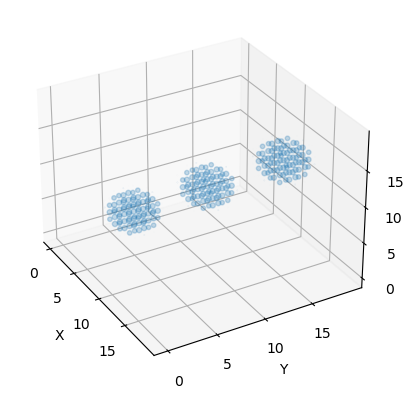

In [ ]:
-6), i*torch.tensor(10e-6), i*torch.tensor(10e-6))# Create the Geometry object with a shared grid
geometry = Tgeometry.Geometry(grid_shape, spatial_resolution, n_bg)

for i in range(1, 4):
    geometry.add_sphere(center=(i*torch.tensor(10e-6), i*torch.tensor(10e-6), i*torch.tensor(10e-6)), radius=5e-6, RI=1.6, softness=1e-12)

grid = geometry.get_grid()
visualization.visualize_grid(grid.numpy(), n_bg.numpy(), factor=10, angle=(30, -30, 0))
# visualization.visualize_grid_vol(grid.numpy(), n_background=n_bg.numpy(), factor=2)

Coordiante system with size: 
 
              X = [0, 40.00 um], Res_X = 0.20 um
              Y = [0, 40.00 um], Res_Y = 0.20 um
              Z = [0, 40.00 um], Res_Z = 0.20 um
              Immersion RI: 1.4600000381469727
      


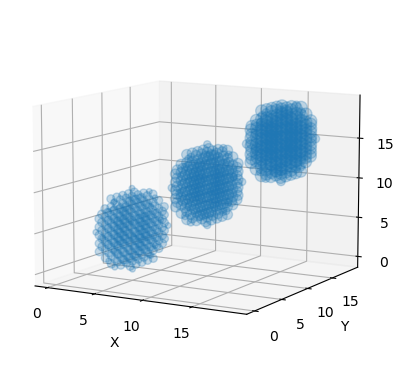

In [8]:
# Create the Geometry object with a shared grid
geometry = Tgeometry.Geometry(grid_shape, spatial_resolution, n_bg)

for i in range(1, 4):
    geometry.add_ellipsoid(center=(i*10e-6, i*10e-6, i*10e-6), radii=(5e-6, 10e-6, 10e-6), RI=1.6 + i*0.2, softness=1e-4)

grid = geometry.get_grid()
visualization.visualize_grid(grid.numpy(), n_bg.numpy(), factor=10, angle=(10, -60, 0))
# visualization.visualize_grid_vol(grid.numpy(), n_background=n_bg.numpy(), factor=2)

Coordiante system with size: 
 
              X = [0, 40.00 um], Res_X = 0.20 um
              Y = [0, 40.00 um], Res_Y = 0.20 um
              Z = [0, 40.00 um], Res_Z = 0.20 um
              Immersion RI: 1.4600000381469727
      


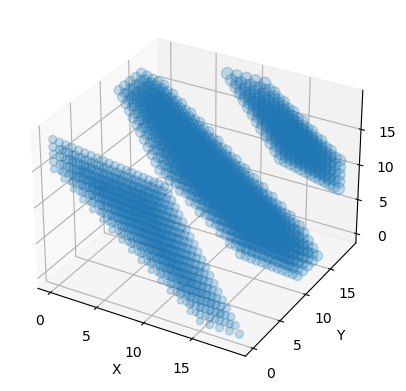

In [9]:
# Create the Geometry object with a shared grid
geometry = Tgeometry.Geometry(grid_shape, spatial_resolution, n_bg)

for i in range(1, 4):
    geometry.add_plane(point=(i*10e-6, i*10e-6, i*10e-6), normal=torch.tensor([0.1, 0.1, 0.1]), RI=1.6 + i*0.2, thickness=5e-6, softness=1e-12)

grid = geometry.get_grid()

visualization.visualize_grid(grid.numpy(), n_bg.numpy(), factor=10, angle=(30, -60, 0))
# visualization.visualize_grid_vol(grid.numpy(), n_background=n_bg.numpy(), factor=2)

#### 2. Optimizing the position of a signle ellipsoid: Softness plays an important role.

In [10]:
# Grid and propagation parameters setup
wl = 640e-9
dx = dy = dz = torch.tensor(200e-9)
nx = ny = nz = 200

n_bg = torch.tensor(1.46)

spatial_resolution = [dx, dy, dz] # x=0->, y=0->, z=0->
grid_shape = [nx, ny, nz]

# Create the Geometry object with a shared grid
geom = Tgeometry.Geometry(grid_shape, spatial_resolution, n_bg)

center_target = torch.tensor([12e-6, 15e-6, 7e-6])
geom.add_ellipsoid(center=center_target, radii=(5e-6, 3e-6, 4e-6), RI=1.6, softness=1e-4)
RI_target = geom.get_grid()

center_est = torch.tensor([10e-6, 10e-6, 10e-6], requires_grad=True, device='cpu')

loss_fn = torch.nn.MSELoss()
# optimizer = torch.optim.Adam([u_est], lr=learning_rate)
optimizer = torch.optim.Adam([center_est], lr=1e-7, weight_decay=1e-5)
epochs = 300

losses = []
dists = []
for i in range(epochs):
    geom.reset_grid()
    geom.add_ellipsoid(center=center_est, radii=(5e-6, 3e-6, 4e-6), RI=1.6, softness=1e-4)
    RI_dist_est = geom.get_grid()
    
    loss = loss_fn(RI_dist_est, RI_target)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.detach().numpy())
    dists.append(np.linalg.norm(center_target.numpy() - center_est.detach().numpy()))
    # print(i, loss.detach().numpy())
print(center_target.numpy(), center_est.detach().numpy())

Coordiante system with size: 
 
              X = [0, 40.00 um], Res_X = 0.20 um
              Y = [0, 40.00 um], Res_Y = 0.20 um
              Z = [0, 40.00 um], Res_Z = 0.20 um
              Immersion RI: 1.4600000381469727
      
[1.2e-05 1.5e-05 7.0e-06] [1.1997263e-05 1.5006851e-05 6.9994262e-06]


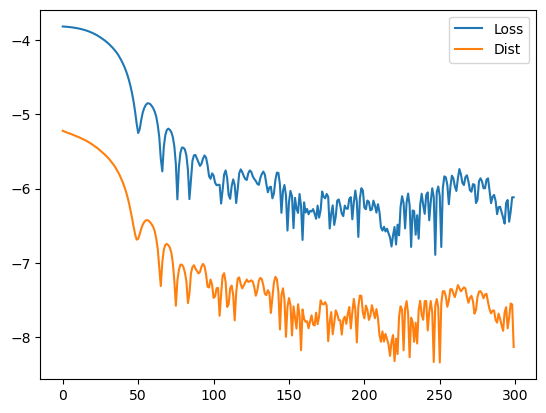

In [11]:
plt.plot(np.log10(losses), label='Loss')
plt.plot(np.log10(np.array(dists)), label='Dist')
plt.legend()
plt.show()

#### 3. Timing ellipsoid generation

In [12]:
# Grid and propagation parameters setup
wl = 640e-9
dx = dy = dz = torch.tensor(200e-9)
nx = ny = nz = 200

n_bg = torch.tensor(1.46)

spatial_resolution = [dx, dy, dz] # x=0->, y=0->, z=0->
grid_shape = [nx, ny, nz]

# Create the Geometry object with a shared grid
geometry = Tgeometry.Geometry(grid_shape, spatial_resolution, n_bg)

Coordiante system with size: 
 
              X = [0, 40.00 um], Res_X = 0.20 um
              Y = [0, 40.00 um], Res_Y = 0.20 um
              Z = [0, 40.00 um], Res_Z = 0.20 um
              Immersion RI: 1.4600000381469727
      


10 elliposids are generated in on average 0.85 seconds


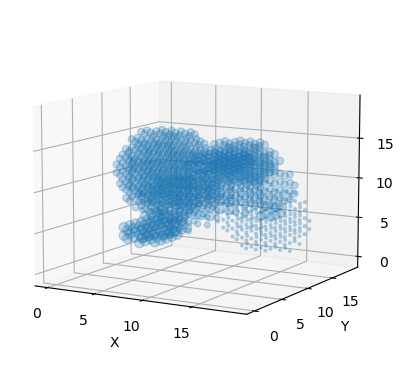

In [13]:
trials = 10
num_elements = 10

start = time.time()
for i in range(trials):
    geometry.reset_grid()

    geometry.add_ellipsoids(centers=torch.rand([num_elements, 3])*20e-6 + 10e-6, radii=torch.rand([num_elements, 3])*10e-6 + 2e-6, 
                            RIs=torch.rand(num_elements)/2 + n_bg, softness=1e-4)

    grid = geometry.get_grid()

stop = time.time()

print(f"{num_elements} elliposids are generated in on average {(stop-start)/trials:.2f} seconds")

visualization.visualize_grid(grid.numpy(), n_bg.numpy(), factor=10, angle=(10, -60, 0))
# visualization.visualize_grid_vol(grid.numpy(), n_background=n_bg.numpy(), factor=2)

#### 4. Generating multiple cubes, spheres and elliposids

In [14]:
# Grid and propagation parameters setup
wl = 640e-9
dx = dy = dz = torch.tensor(200e-9)
nx = ny = nz = 200

n_bg = torch.tensor(1.46)

spatial_resolution = [dx, dy, dz] # x=0->, y=0->, z=0->
grid_shape = [nx, ny, nz]

# Create the Geometry object with a shared grid
geometry = Tgeometry.Geometry(grid_shape, spatial_resolution, n_bg)

Coordiante system with size: 
 
              X = [0, 40.00 um], Res_X = 0.20 um
              Y = [0, 40.00 um], Res_Y = 0.20 um
              Z = [0, 40.00 um], Res_Z = 0.20 um
              Immersion RI: 1.4600000381469727
      


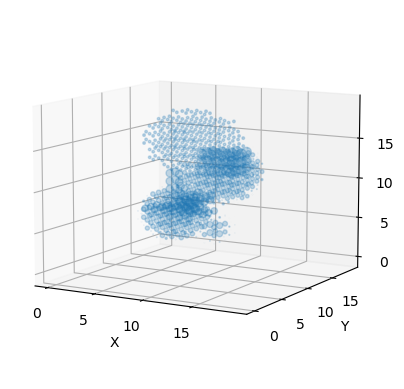

In [15]:
geometry.reset_grid()

num_elements = 3

geometry.add_cubes(centers=torch.rand([num_elements, 3])*20e-6 + 10e-6, side_lengths=torch.rand(num_elements)*10e-6 + 2e-6, 
                        RIs=torch.rand(num_elements)/2 + n_bg, softness=1e-9)
geometry.add_spheres(centers=torch.rand([num_elements, 3])*20e-6 + 10e-6, radii=torch.rand(num_elements)*10e-6 + 2e-6, 
                        RIs=torch.rand(num_elements)/2 + n_bg, softness=1e-12)
geometry.add_ellipsoids(centers=torch.rand([num_elements, 3])*20e-6 + 10e-6, radii=torch.rand([num_elements, 3])*10e-6 + 2e-6, 
                        RIs=torch.rand(num_elements)/2 + n_bg, softness=1e-4)

grid = geometry.get_grid()

visualization.visualize_grid(grid.numpy(), n_bg.numpy(), factor=10, angle=(10, -60, 0))
# visualization.visualize_grid_vol(grid.numpy(), n_background=n_bg.numpy(), factor=2)